# 1.0 Imports

In [129]:
import pandas as pd
import numpy as np
from IPython.display import Image

import seaborn as sns
import matplotlib.pyplot as plt

# Funções

# 2.0 Carregando os dados

In [75]:
df = pd.read_excel('/home/lucas/projetos/churn_IBM/dataset/Telco_customer_churn.xlsx')

# 3.0 Verificando os dados

In [76]:
#.T transpõe linhas e colunas
df.head().T

,0,1,2,3,4
CustomerID,3668-QPYBK,9237-HQITU,9305-CDSKC,7892-POOKP,0280-XJGEX
Count,1,1,1,1,1
Country,United States,United States,United States,United States,United States
State,California,California,California,California,California
City,Los Angeles,Los Angeles,Los Angeles,Los Angeles,Los Angeles
Zip Code,90003,90005,90006,90010,90015
Lat Long,"33.964131, -118.272783","34.059281, -118.30742","34.048013, -118.293953","34.062125, -118.315709","34.039224, -118.266293"
Latitude,33.964131,34.059281,34.048013,34.062125,34.039224
Longitude,-118.272783,-118.30742,-118.293953,-118.315709,-118.266293
Gender,Male,Female,Female,Female,Male


# 4.0 Discrição dos dados

In [77]:
df1 = df.copy()

#### 4.1 Dimensões

In [78]:
print(f'O número de linhas é {df1.shape[0]}')
print(f'O número de colunas é {df1.shape[1]}')

O número de linhas é 7043
O número de colunas é 33


In [79]:
df.columns

Index(['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code',
       'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen',
       'Partner', 'Dependents', 'Tenure Months', 'Phone Service',
       'Multiple Lines', 'Internet Service', 'Online Security',
       'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV',
       'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method',
       'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value',
       'Churn Score', 'CLTV', 'Churn Reason'],
      dtype='str')

#### 4.2 Data Types

In [80]:
#passa o types e ainda me fala os NULL
df1.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   str    
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   str    
 3   State              7043 non-null   str    
 4   City               7043 non-null   str    
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   str    
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   str    
 10  Senior Citizen     7043 non-null   str    
 11  Partner            7043 non-null   str    
 12  Dependents         7043 non-null   str    
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   str    
 15  Multiple Lines     7043 non-null   str    
 16  Internet Service   7043 non-null   

#### 4.3 Check NA

In [81]:
df1.isna().sum()

#churn reason tem bastante, porque nem todo mundo responde sobre a saída da emrpresa

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64

#### 4.4 Check Duplicatas

In [82]:
df1.duplicated().sum()

np.int64(0)

#### 4.5 Analise Descritiva

In [83]:
#separando as variáveis categórcas e numéricas para anlise

num_attributes = df.select_dtypes(include = ['int64', 'float64'])

cat_attributes = df.select_dtypes(exclude = ['int64', 'float64'])


In [84]:
print(cat_attributes.head().T)

                                              0                      1  \
CustomerID                           3668-QPYBK             9237-HQITU   
Country                           United States          United States   
State                                California             California   
City                                Los Angeles            Los Angeles   
Lat Long                 33.964131, -118.272783  34.059281, -118.30742   
Gender                                     Male                 Female   
Senior Citizen                               No                     No   
Partner                                      No                     No   
Dependents                                   No                    Yes   
Phone Service                               Yes                    Yes   
Multiple Lines                               No                     No   
Internet Service                            DSL            Fiber optic   
Online Security                       

In [85]:
print(num_attributes.head().T)

                            0             1             2             3  \
Count                1.000000      1.000000      1.000000      1.000000   
Zip Code         90003.000000  90005.000000  90006.000000  90010.000000   
Latitude            33.964131     34.059281     34.048013     34.062125   
Longitude         -118.272783   -118.307420   -118.293953   -118.315709   
Tenure Months        2.000000      2.000000      8.000000     28.000000   
Monthly Charges     53.850000     70.700000     99.650000    104.800000   
Churn Value          1.000000      1.000000      1.000000      1.000000   
Churn Score         86.000000     67.000000     86.000000     84.000000   
CLTV              3239.000000   2701.000000   5372.000000   5003.000000   

                            4  
Count                1.000000  
Zip Code         90015.000000  
Latitude            34.039224  
Longitude         -118.266293  
Tenure Months       49.000000  
Monthly Charges    103.700000  
Churn Value          1.00

In [86]:
#traz mais informações dos dados com describe
cat_attributes.describe().T

,count,unique,top,freq
CustomerID,7043,7043,3668-QPYBK,1
Country,7043,1,United States,7043
State,7043,1,California,7043
City,7043,1129,Los Angeles,305
Lat Long,7043,1652,"33.964131, -118.272783",5
Gender,7043,2,Male,3555
Senior Citizen,7043,2,No,5901
Partner,7043,2,No,3641
Dependents,7043,2,No,5416
Phone Service,7043,2,Yes,6361


In [87]:
num_attributes.describe().T

,count,mean,std,min,25%,50%,75%,max
Count,7043.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
Zip Code,7043.0,93521.964646,1865.794555,90001.000000,92102.000000,93552.000000,95351.000000,96161.000000
Latitude,7043.0,36.282441,2.455723,32.555828,34.030915,36.391777,38.224869,41.962127
Longitude,7043.0,-119.798880,2.157889,-124.301372,-121.815412,-119.730885,-118.043237,-114.192901
Tenure Months,7043.0,32.371149,24.559481,0.000000,9.000000,29.000000,55.000000,72.000000
Monthly Charges,7043.0,64.761692,30.090047,18.250000,35.500000,70.350000,89.850000,118.750000
Churn Value,7043.0,0.265370,0.441561,0.000000,0.000000,0.000000,1.000000,1.000000
Churn Score,7043.0,58.699418,21.525131,5.000000,40.000000,61.000000,75.000000,100.000000
CLTV,7043.0,4400.295755,1183.057152,2003.000000,3469.000000,4527.000000,5380.500000,6500.000000


#### 4.5.1 Variáveis numéricas

In [88]:
#tendencia central - média e mediana

ct1 = pd.DataFrame(num_attributes.mean()).T

ct2 = pd.DataFrame(num_attributes.median()).T

#dispersão: std, minimo, maximo, range, skewness, kurtosis

d1 = pd.DataFrame(num_attributes.std()).T
d2 = pd.DataFrame(num_attributes.min()).T
d3 = pd.DataFrame(num_attributes.max()).T
d4 = pd.DataFrame(num_attributes.max() - num_attributes.min()).T
d5 = pd.DataFrame(num_attributes.skew()).T
d6 = pd.DataFrame(num_attributes.kurtosis()).T

#outras formas de calcular
#d7 = num_attributes.apply(np.ptp)
#d8 = num_attributes.std()
#d1 = pd.DataFrame.std(num_attributes).T

#concatenar os resultados
m = pd.concat([ct1, ct2, d1, d2, d3, d4, d5, d6]).T.reset_index()
m.columns = ['attributes', 'mean', 'median', 'std', 'min', 'max', 'range', 'skew', 'kurtosis']
m

,attributes,mean,median,std,min,max,range,skew,kurtosis
0,Count,1.000000,1.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000
1,Zip Code,93521.964646,93552.000000,1865.794555,90001.000000,96161.000000,6160.000000,-0.251463,-1.154043
2,Latitude,36.282441,36.391777,2.455723,32.555828,41.962127,9.406299,0.303867,-1.135607
3,Longitude,-119.798880,-119.730885,2.157889,-124.301372,-114.192901,10.108471,-0.040792,-1.136050
4,Tenure Months,32.371149,29.000000,24.559481,0.000000,72.000000,72.000000,0.239540,-1.387372
5,Monthly Charges,64.761692,70.350000,30.090047,18.250000,118.750000,100.500000,-0.220524,-1.257260
6,Churn Value,0.265370,0.000000,0.441561,0.000000,1.000000,1.000000,1.063031,-0.870211
7,Churn Score,58.699418,61.000000,21.525131,5.000000,100.000000,95.000000,-0.089840,-1.005679
8,CLTV,4400.295755,4527.000000,1183.057152,2003.000000,6500.000000,4497.000000,-0.311602,-0.934032


#### 4.5.2 Variáveis categóricas

In [89]:
ct3 = cat_attributes.nunique()
ct3

CustomerID           7043
Country                 1
State                   1
City                 1129
Lat Long             1652
Gender                  2
Senior Citizen          2
Partner                 2
Dependents              2
Phone Service           2
Multiple Lines          3
Internet Service        3
Online Security         3
Online Backup           3
Device Protection       3
Tech Support            3
Streaming TV            3
Streaming Movies        3
Contract                3
Paperless Billing       2
Payment Method          4
Total Charges        6531
Churn Label             2
Churn Reason           20
dtype: int64

#### 4.5.3 Corrigindo variáveis categóricas

In [ ]:
#onde é Yes ou No, tinha 3 resposta, deixando apenas Yes ou No 


#cat_attributes['Multiple Lines'] = cat_attributes['Multiple Lines'].apply(lambda x: 'Yes' if x == 'Yes' else 'No')
#cat_attributes['Online Security'] = cat_attributes['Online Security'].apply(lambda x: 'Yes' if x == 'Yes' else 'No')
#cat_attributes['Online Backup'] = cat_attributes['Online Backup'].apply(lambda x: 'Yes' if x == 'Yes' else 'No')
#cat_attributes['Device Protection'] = cat_attributes['Device Protection'].apply(lambda x: 'Yes' if x == 'Yes' else 'No')
#cat_attributes['Tech Support'] = cat_attributes['Tech Support'].apply(lambda x: 'Yes' if x == 'Yes' else 'No')
#cat_attributes['Streaming TV'] = cat_attributes['Streaming TV'].apply(lambda x: 'Yes' if x == 'Yes' else 'No')
#cat_attributes['Streaming Movies'] = cat_attributes['Streaming Movies'].apply(lambda x: 'Yes' if x == 'Yes' else 'No')

features = ['Multiple Lines', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies']

for i in features:
    cat_attributes[i] = cat_attributes[i].apply(lambda x: 'Yes' if x == 'Yes' else 'No')


cat_attributes.nunique()


#cat_attributes['Multiple Lines'].unique()

CustomerID           7043
Country                 1
State                   1
City                 1129
Lat Long             1652
Gender                  2
Senior Citizen          2
Partner                 2
Dependents              2
Phone Service           2
Multiple Lines          2
Internet Service        3
Online Security         2
Online Backup           2
Device Protection       2
Tech Support            2
Streaming TV            2
Streaming Movies        2
Contract                3
Paperless Billing       2
Payment Method          4
Total Charges        6531
Churn Label             2
Churn Reason           20
dtype: int64

In [111]:
num_attributes.groupby('Monthly Charges').nunique()

,Count,Zip Code,Latitude,Longitude,Tenure Months,Churn Value,Churn Score,CLTV
Monthly Charges,,,,,,,,
18.25,1,1,1,1,1,1,1,1
18.40,1,1,1,1,1,1,1,1
18.55,1,1,1,1,1,1,1,1
18.70,1,2,2,2,2,1,2,2
18.75,1,1,1,1,1,1,1,1
...,...,...,...,...,...,...,...,...
118.20,1,1,1,1,1,1,1,1
118.35,1,1,1,1,1,1,1,1
118.60,1,2,2,2,2,1,2,2


# 5.0 Mapa Mental

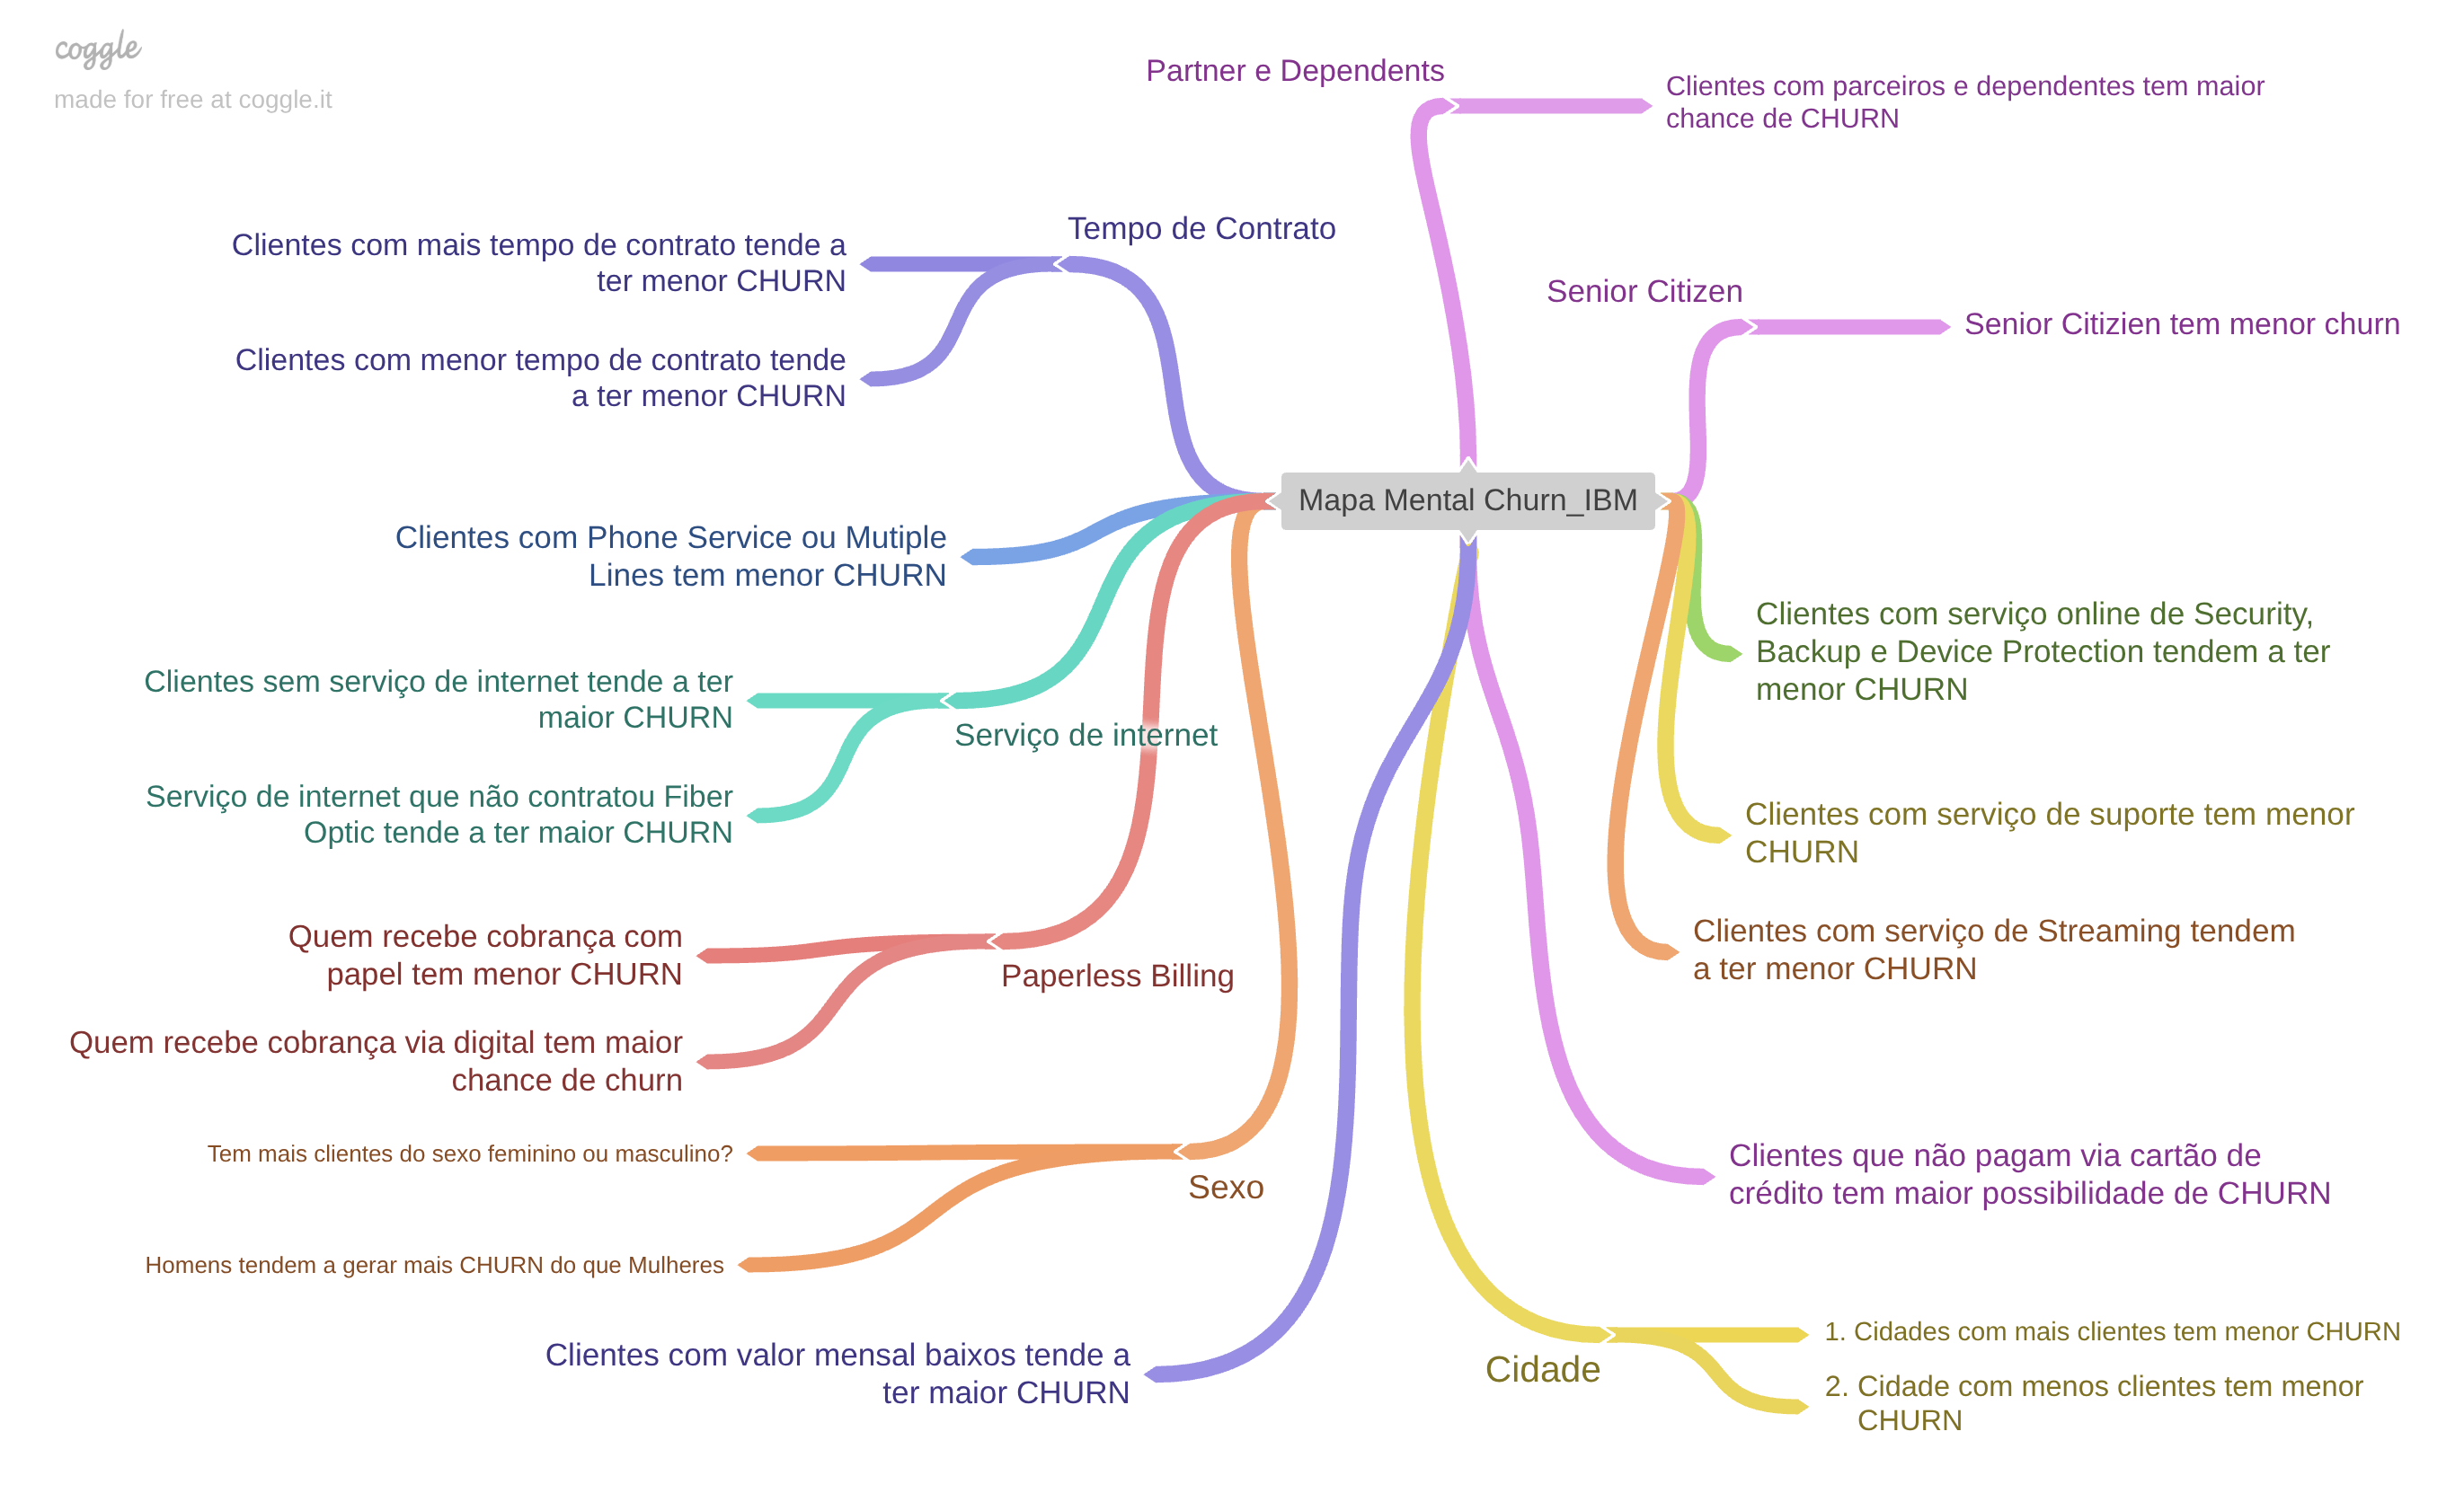

In [113]:
Image('imagens/Mapa_Mental_Churn_IBM.png')

#### 5.1 Criação de Hipoteses

#### 5.2 Hipóteses:

- Clientes com parceiros e dependentes tem maior chance de CHURN
- Senior Citizien tem menor CHURN
- Clientes com serviço online de Security, Backup e Device Protection tendem a ter menor CHURN
- Clientes com serviço de suporte tem menor CHURN
- Clientes com serviço de Streaming tendem a ter menor CHURN
- Clientes que não pagam via cartão de crédito tem maior possibilidade de CHURN
- Cidade:
    - Cidades com mais clientes tem menor CHURN
    - Cidade com menos clientes tem menor CHURN
- Clientes com valor mensal baixos tende a ter maior CHURN
- Sexo:
    - Homens tendem a gerar mais CHURN do que Mulheres
    - Tem mais clientes do sexo feminino ou masculino?
- Paperless Billing:
    - Quem recebe cobrança via digital tem maior chance de churn
    - Quem recebe cobrança com papel tem menor CHURN
- Serviço de internet:
    - Serviço de internet que não contratou Fiber Optic tende a ter maior CHURN
    - Clientes sem serviço de internet tende a ter maior CHURN
- Clientes com Phone Service ou Mutiple Lines tem menor CHURN
- Tempo De Contrato:
    - Clientes com menor tempo de contrato tende a ter menor CHURN
    - Clientes com mais tempo de contrato tende a ter menor CHURN


# 6.0 Feature Engineering

In [ ]:
df2 = df.copy()

In [126]:
features = ['Multiple Lines', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies']

for i in features:
    df2[i] = df2[i].apply(lambda x: 'Yes' if x == 'Yes' else 'No')


df2['Churn Value'] = df2['Churn Value'].apply(lambda x: 'No' if x == 0 else 'Yes')



# 7.0 Filtragem de Variáveis

In [127]:
df3 = df2.copy()

df3 = df3.drop(['CustomerID', 'Count', 'Lat Long'], axis = 1)

df3.shape[1]

30

# 8.0 E.D.A

### 8.1 Análise Univariada

#### 8.1.1 Variável Resposta

<Axes: xlabel='Churn Value', ylabel='Count'>

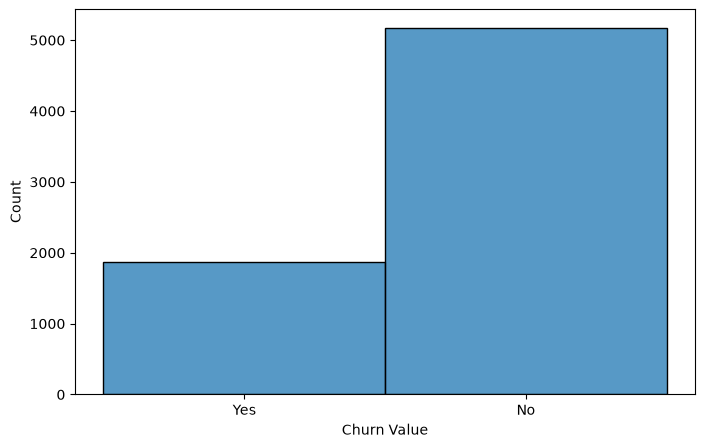

In [149]:
df3['Churn Value'].value_counts(normalize = True)

plt.figure(figsize = (8, 5))
sns.histplot(df3['Churn Value'])

#### 8.1.2 Variáveis Numéricas

#### 8.1.3 Variáveis Categóricas